# 03 — Bayesian Analysis

Frequentist testing answers: *"Is this result unlikely under the null?"*  
Bayesian testing answers: *"What is the probability treatment is actually better?"*

The second question is what business stakeholders actually want to know.

**Method:** Beta-Binomial conjugate model (no PyMC, no heavy dependencies)

```
Prior:     p ~ Beta(1, 1)          ← uniform, no prior assumption
Posterior: p ~ Beta(1 + conversions,  1 + non-conversions)   ← exact update
```

Then 200k Monte Carlo samples to estimate everything downstream.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
N = 200_000

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.facecolor': 'white',
                     'axes.spines.top': False,
                     'axes.spines.right': False})
%matplotlib inline

In [2]:
df = pd.read_csv('ab_data_clean.csv')

ctrl = df[df['group'] == 'control']
trt  = df[df['group'] == 'treatment']

n_ctrl,    n_trt    = len(ctrl),              len(trt)
conv_ctrl, conv_trt = ctrl['converted'].sum(), trt['converted'].sum()

print(f'Control:   n={n_ctrl:,}   conversions={conv_ctrl:,}')
print(f'Treatment: n={n_trt:,}   conversions={conv_trt:,}')

Control:   n=144,319   conversions=17,375
Treatment: n=144,316   conversions=17,130


## Posterior Parameters (Beta conjugate update)

In [3]:
# Posterior parameters using Beta(1,1) prior
a_ctrl = 1 + conv_ctrl
b_ctrl = 1 + (n_ctrl - conv_ctrl)
a_trt  = 1 + conv_trt
b_trt  = 1 + (n_trt - conv_trt)

# Print posterior distributions
print(f"Control posterior:   Beta({a_ctrl}, {b_ctrl})")
print(f"Treatment posterior: Beta({a_trt}, {b_trt})")

# Posterior means
mean_ctrl = a_ctrl / (a_ctrl + b_ctrl)
mean_trt  = a_trt  / (a_trt  + b_trt)

print(f"\nPosterior mean control:   {mean_ctrl*100:.5f}%")
print(f"Posterior mean treatment: {mean_trt*100:.5f}%")

# Note about prior influence
print("\nWith this many observations the uniform prior has negligible influence.")

Control posterior:   Beta(17376, 126945)
Treatment posterior: Beta(17131, 127187)

Posterior mean control:   12.03983%
Posterior mean treatment: 11.87031%

With this many observations the uniform prior has negligible influence.


## Monte Carlo Sampling

In [4]:
samples_ctrl = np.random.beta(a_ctrl, b_ctrl, N)
samples_trt  = np.random.beta(a_trt,  b_trt,  N)

prob_trt_better = (samples_trt > samples_ctrl).mean()

print(f'P(treatment > control): {prob_trt_better:.4f}  ({prob_trt_better*100:.2f}%)')
print(f'P(control > treatment): {1-prob_trt_better:.4f}  ({(1-prob_trt_better)*100:.2f}%)')

P(treatment > control): 0.0813  (8.13%)
P(control > treatment): 0.9187  (91.87%)


## Expected Loss

More useful than P(B > A) for actual decisions.

- **Loss if we ship** = how much conversion we lose on average if treatment is worse  
- **Loss if we don't ship** = how much conversion we miss if treatment is actually better

→ Choose the action with the lower expected loss.


In [5]:
loss_ship    = np.maximum(samples_ctrl - samples_trt, 0).mean()
loss_no_ship = np.maximum(samples_trt  - samples_ctrl, 0).mean()

print(f'Expected loss if we SHIP:     {loss_ship*100:.5f} pp')
print(f'Expected loss if we NO-SHIP:  {loss_no_ship*100:.5f} pp')
print()
print('Bayesian recommendation: ' + ('SHIP' if loss_ship < loss_no_ship else 'DO NOT SHIP'))

Expected loss if we SHIP:     0.17439 pp
Expected loss if we NO-SHIP:  0.00447 pp

Bayesian recommendation: DO NOT SHIP


## 95% Credible Interval on the Difference

In [6]:
# Difference in posterior samples
diff = samples_trt - samples_ctrl

# 95% credible intervals
ci_diff     = np.percentile(diff, [2.5, 97.5])
ci_ctrl_bay = np.percentile(samples_ctrl, [2.5, 97.5])
ci_trt_bay  = np.percentile(samples_trt,  [2.5, 97.5])

# Print intervals
print(f"Control   95% CI: [{ci_ctrl_bay[0]*100:.4f}%, {ci_ctrl_bay[1]*100:.4f}%]")
print(f"Treatment 95% CI: [{ci_trt_bay[0]*100:.4f}%, {ci_trt_bay[1]*100:.4f}%]")

print(f"\nDifference 95% CI: [{ci_diff[0]*100:.4f} pp, {ci_diff[1]*100:.4f} pp]")

# Interpret results
if ci_diff[0] > 0:
    print("Entire CI above 0 → treatment is reliably better")
elif ci_diff[1] < 0:
    print("Entire CI below 0 → control is reliably better")
else:
    pct = stats.percentileofscore(diff, 0)
    print(f"CI straddles 0 → direction is uncertain (zero at {pct:.1f}th percentile)")

Control   95% CI: [11.8720%, 12.2079%]
Treatment 95% CI: [11.7020%, 12.0375%]

Difference 95% CI: [-0.4073 pp, 0.0682 pp]
CI straddles 0 → direction is uncertain (zero at 91.9th percentile)


## Visualisation

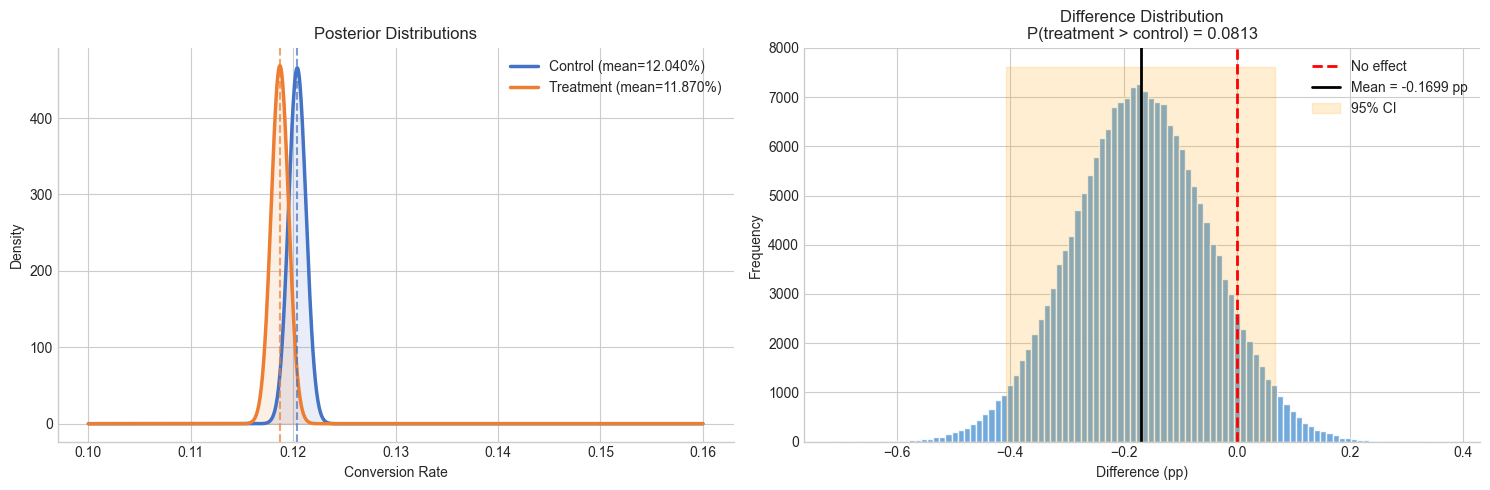

In [7]:
# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Posterior distributions for control and treatment
ax = axes[0]
x = np.linspace(0.10, 0.16, 1000)
pm_ctrl = a_ctrl / (a_ctrl + b_ctrl)
pm_trt  = a_trt  / (a_trt  + b_trt)

ax.plot(x, stats.beta.pdf(x, a_ctrl, b_ctrl), color='#4472C4', lw=2.5,
        label=f"Control (mean={pm_ctrl*100:.3f}%)")
ax.plot(x, stats.beta.pdf(x, a_trt, b_trt), color='#ED7D31', lw=2.5,
        label=f"Treatment (mean={pm_trt*100:.3f}%)")
ax.fill_between(x, stats.beta.pdf(x, a_ctrl, b_ctrl), alpha=0.12, color='#4472C4')
ax.fill_between(x, stats.beta.pdf(x, a_trt, b_trt), alpha=0.12, color='#ED7D31')
ax.axvline(pm_ctrl, color='#4472C4', linestyle='--', alpha=0.7)
ax.axvline(pm_trt,  color='#ED7D31', linestyle='--', alpha=0.7)
ax.set_title("Posterior Distributions")
ax.set_xlabel("Conversion Rate")
ax.set_ylabel("Density")
ax.legend()

# Distribution of differences
ax2 = axes[1]
ax2.hist(diff*100, bins=100, color='#5B9BD5', edgecolor='white', alpha=0.85)
ymax = ax2.get_ylim()[1]
ax2.axvline(0, color='red', linestyle='--', lw=2, label="No effect")
ax2.axvline(diff.mean()*100, color='black', lw=2, label=f"Mean = {diff.mean()*100:.4f} pp")
ax2.fill_betweenx([0, ymax], ci_diff[0]*100, ci_diff[1]*100,
                  alpha=0.18, color='orange', label="95% CI")
ax2.set_title(f"Difference Distribution\nP(treatment > control) = {prob_trt_better:.4f}")
ax2.set_xlabel("Difference (pp)")
ax2.set_ylabel("Frequency")
ax2.legend()

# Show plot
plt.tight_layout()
plt.show()

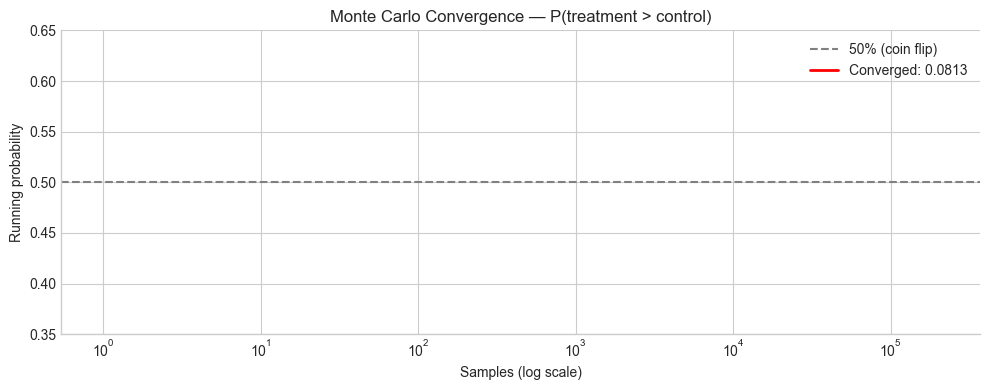

In [11]:
# Convergence check to see if estimate stabilises
fig, ax = plt.subplots(figsize=(10, 4))

# Running probability that treatment > control
running = np.cumsum(samples_trt > samples_ctrl) / np.arange(1, N+1)
ax.plot(running, color='#4472C4', lw=1.2)

# Reference lines
ax.axhline(0.5, color='gray', linestyle='--', lw=1.5, label="50% (coin flip)")
ax.axhline(prob_trt_better, color='red', lw=2, label=f"Converged: {prob_trt_better:.4f}")

# Formatting
ax.set_xscale("log")
ax.set_title("Monte Carlo Convergence — P(treatment > control)")
ax.set_xlabel("Samples (log scale)")
ax.set_ylabel("Running probability")
ax.set_ylim(0.35, 0.65)
ax.legend()

# Show plot
plt.tight_layout()
plt.show()

In [9]:
print('BAYESIAN SUMMARY')
print('='*50)
print(f'P(treatment > control):     {prob_trt_better:.4f}')
print(f'Expected loss (ship):       {loss_ship*100:.5f} pp')
print(f'Expected loss (no-ship):    {loss_no_ship*100:.5f} pp')
print(f'95% CI on difference:       [{ci_diff[0]*100:.4f},  {ci_diff[1]*100:.4f}] pp')
print()
if   prob_trt_better < 0.50: print('Treatment is more likely to HURT conversion than help.')
elif prob_trt_better < 0.90: print('Uncertain — not enough confidence to ship.')
else:                         print('Strong evidence treatment outperforms control.')

BAYESIAN SUMMARY
P(treatment > control):     0.0813
Expected loss (ship):       0.17439 pp
Expected loss (no-ship):    0.00447 pp
95% CI on difference:       [-0.4073,  0.0682] pp

Treatment is more likely to HURT conversion than help.
